In [11]:
from pathlib import Path
import json
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
import umap

plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["axes.grid"] = True

TREE_JSON = Path("../data/processed/raptor_tree/raptor_tree.json")
NODES_JSONL = Path("../data/processed/raptor_tree/raptor_nodes.jsonl")
LEAF_JSONL = Path("../data/processed/raptor_tree/leaf_nodes.jsonl")
LEAF_EMB = Path("../data/processed/raptor_tree/leaf_embeddings.npy")

# chunks gốc sau preprocess
CHUNKS_JSONL = Path("../data/processed/preprocess_output/ngo-doc/chunks.jsonl")

In [12]:
def read_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

tree = json.loads(TREE_JSON.read_text(encoding="utf-8"))
nodes = read_jsonl(NODES_JSONL)
leaves = read_jsonl(LEAF_JSONL)
chunks = read_jsonl(CHUNKS_JSONL)

nodes_df = pd.DataFrame(nodes)
leaves_df = pd.DataFrame(leaves)
chunks_df = pd.DataFrame(chunks)

print(json.dumps(tree["stats"], ensure_ascii=False, indent=2))
print(nodes_df.head(2).to_dict(orient="records"))

{
  "leaf_nodes": 1037,
  "total_nodes": 1081,
  "levels": 5,
  "root_node_ids": [
    "node_ad487ae3f889322f"
  ]
}
[{'node_id': 'leaf_7acd0fbaa913c3d0', 'source_chunk_id': '28d90f762769fcfc', 'depth': 0, 'text': 'BỘ Y TẾ > CHẨN ĐOÁN VÀ XỬ TRÍ NGỘ ĐỘC\n\n(Ban hành kèm theo Quyết định số 3610/QĐ-BYT ngày 31/8/2015\ncủa Bộ trưởng Bộ Y tế)\n\nHà Nội, 2015', 'token_estimate': 39, 'is_leaf': True, 'child_node_ids': [], 'source_docs': ['Ngo-doc.pdf'], 'source_pages': [1], 'chunk_type': 'text', 'chunk_index': 1.0, 'metadata': {'source_jsonl': 'data\\processed\\preprocess_output\\ngo-doc\\chunks.jsonl', 'original_metadata': {'headings': ['BỘ Y TẾ', 'CHẨN ĐOÁN VÀ XỬ TRÍ NGỘ ĐỘC'], 'page_headings': ['BỘ Y TẾ', 'HƯỚNG DẪN', 'CHẨN ĐOÁN VÀ XỬ TRÍ NGỘ ĐỘC'], 'section_index': 1, 'paragraph_index': 1, 'semantic_type': 'treatment', 'max_chars': 1400, 'overlap_words': 0, 'text_block_count': 5, 'text_blocks_after_table_filter': 5, 'page_markdown_path': 'data/processed/preprocess_output/ngo-doc/markdown_

In [13]:
print("Nodes by depth:")
print(nodes_df["depth"].value_counts().sort_index())

print("\nLeaf / non-leaf:")
print(nodes_df["is_leaf"].value_counts())

print("\nConfig:")
print(json.dumps(tree["config"], ensure_ascii=False, indent=2))

Nodes by depth:
depth
0    1037
1      34
2       6
3       3
4       1
Name: count, dtype: int64

Leaf / non-leaf:
is_leaf
True     1037
False      44
Name: count, dtype: int64

Config:
{
  "input_path": "data\\processed\\preprocess_output",
  "output_dir": "data\\processed\\raptor_tree",
  "embed_model": "BAAI/bge-m3",
  "embedding_backend": "auto",
  "embedding_dim": 1024,
  "max_depth": 4,
  "umap_neighbors": 15,
  "umap_components": 8,
  "bic_max_k": 6,
  "min_cluster_size": 3,
  "max_cluster_tokens": 9000,
  "soft_threshold": 0.3,
  "max_memberships": 1,
  "summary_backend_requested": "modal",
  "modal_batch_size": 8,
  "modal_embed_batch_size": 96
}


In [14]:
parent_map = defaultdict(list)
children_map = {}

for node in nodes:
    node_id = node["node_id"]
    child_ids = node.get("child_node_ids") or []
    children_map[node_id] = child_ids
    for c in child_ids:
        parent_map[c].append(node_id)

node_depth = nodes_df.set_index("node_id")["depth"].to_dict()

def get_parent_chains(node_id, max_depth=10):
    paths = []

    def dfs(cur, path, visited):
        if len(path) > max_depth:
            paths.append(path[:])
            return

        parents = parent_map.get(cur, [])
        if not parents:
            paths.append(path[:])
            return

        for p in parents:
            if p in visited:
                continue
            visited.add(p)
            path.append(p)
            dfs(p, path, visited)
            path.pop()
            visited.remove(p)

    dfs(node_id, [node_id], {node_id})
    return paths

sample_leaf = leaves_df.iloc[0]["node_id"]
print("Sample leaf:", sample_leaf)
print("Parent chains:")
for p in get_parent_chains(sample_leaf):
    print(" -> ".join(p))

Sample leaf: leaf_7acd0fbaa913c3d0
Parent chains:
leaf_7acd0fbaa913c3d0 -> node_d8ad23cac13bac4c -> node_c53e6c853cb50147 -> node_f26691dbece2765c -> node_ad487ae3f889322f


In [15]:
# chunks.jsonl là nơi có page_number gốc
chunk_page_map = {
    row["id"]: row["page_number"]
    for _, row in chunks_df.iterrows()
    if "id" in row and "page_number" in row
}

leaves_df["page_number"] = leaves_df["source_chunk_id"].map(chunk_page_map)

print("Page mapping match rate:")
print(leaves_df["page_number"].notna().mean())

leaves_df[["node_id", "source_chunk_id", "source_pages", "page_number"]].head(10)

Page mapping match rate:
1.0


,node_id,source_chunk_id,source_pages,page_number
0,leaf_7acd0fbaa913c3d0,28d90f762769fcfc,[1],1
1,leaf_9f5e0e35d9f8ad41,e4e25380b42a9f50,[1],1
2,leaf_f2492a0dd1a24fcc,0841b4d885ccd95e,[2],2
3,leaf_9efab2e526ee2d33,8c7b083c2b6838c7,[3],3
4,leaf_6b8902f7ab8d9c5a,a0de5ea224eeb79a,[4],4
5,leaf_c0217fb5f4778cd7,97a1be35a28df671,[4],4
6,leaf_22193cb171db452d,7b9d35790145f1fe,[4],4
7,leaf_da7944a40ea3b3b9,2affc9f1e5617194,[5],5
8,leaf_e228587bfd0cb12d,66b9bee7907b5eb6,[5],5
9,leaf_46b8ecc6fad1b896,870bf975b346531b,[6],6


In [16]:
# chunks.jsonl là nơi có page_number gốc
chunk_page_map = {
    row["id"]: row["page_number"]
    for _, row in chunks_df.iterrows()
    if "id" in row and "page_number" in row
}

leaves_df["page_number"] = leaves_df["source_chunk_id"].map(chunk_page_map)

print("Page mapping match rate:")
print(leaves_df["page_number"].notna().mean())

leaves_df[["node_id", "source_chunk_id", "source_pages", "page_number"]].head(10)

Page mapping match rate:
1.0


,node_id,source_chunk_id,source_pages,page_number
0,leaf_7acd0fbaa913c3d0,28d90f762769fcfc,[1],1
1,leaf_9f5e0e35d9f8ad41,e4e25380b42a9f50,[1],1
2,leaf_f2492a0dd1a24fcc,0841b4d885ccd95e,[2],2
3,leaf_9efab2e526ee2d33,8c7b083c2b6838c7,[3],3
4,leaf_6b8902f7ab8d9c5a,a0de5ea224eeb79a,[4],4
5,leaf_c0217fb5f4778cd7,97a1be35a28df671,[4],4
6,leaf_22193cb171db452d,7b9d35790145f1fe,[4],4
7,leaf_da7944a40ea3b3b9,2affc9f1e5617194,[5],5
8,leaf_e228587bfd0cb12d,66b9bee7907b5eb6,[5],5
9,leaf_46b8ecc6fad1b896,870bf975b346531b,[6],6


In [17]:
leaf_view = leaves_df.copy()
leaf_view["page_number"] = leaf_view["source_pages"].apply(first_page)
leaf_view = leaf_view.sort_values(["page_number", "chunk_index"], ascending=[True, True])

leaf_view[[
    "node_id", "source_chunk_id", "page_number", "chunk_index", "token_estimate"
]].head(20)

,node_id,source_chunk_id,page_number,chunk_index,token_estimate
0,leaf_7acd0fbaa913c3d0,28d90f762769fcfc,1,1,39
1,leaf_9f5e0e35d9f8ad41,e4e25380b42a9f50,1,1,43
2,leaf_f2492a0dd1a24fcc,0841b4d885ccd95e,2,1,3
3,leaf_9efab2e526ee2d33,8c7b083c2b6838c7,3,1,134
4,leaf_6b8902f7ab8d9c5a,a0de5ea224eeb79a,4,1,42
5,leaf_c0217fb5f4778cd7,97a1be35a28df671,4,2,23
6,leaf_22193cb171db452d,7b9d35790145f1fe,4,3,26
7,leaf_da7944a40ea3b3b9,2affc9f1e5617194,5,1,21
8,leaf_e228587bfd0cb12d,66b9bee7907b5eb6,5,2,28
9,leaf_46b8ecc6fad1b896,870bf975b346531b,6,1,214


In [18]:
embeddings = np.load(LEAF_EMB)
print("Leaf embeddings shape:", embeddings.shape)
print("Leaf count:", len(leaves_df))

assert len(leaves_df) == embeddings.shape[0], "Số leaf và số embedding không khớp"

Leaf embeddings shape: (1037, 1024)
Leaf count: 1037


# Trực quan hóa leaf clusters bằng UMAP

f:\ptit\anam4_ki2\InformationRetrieval\project\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


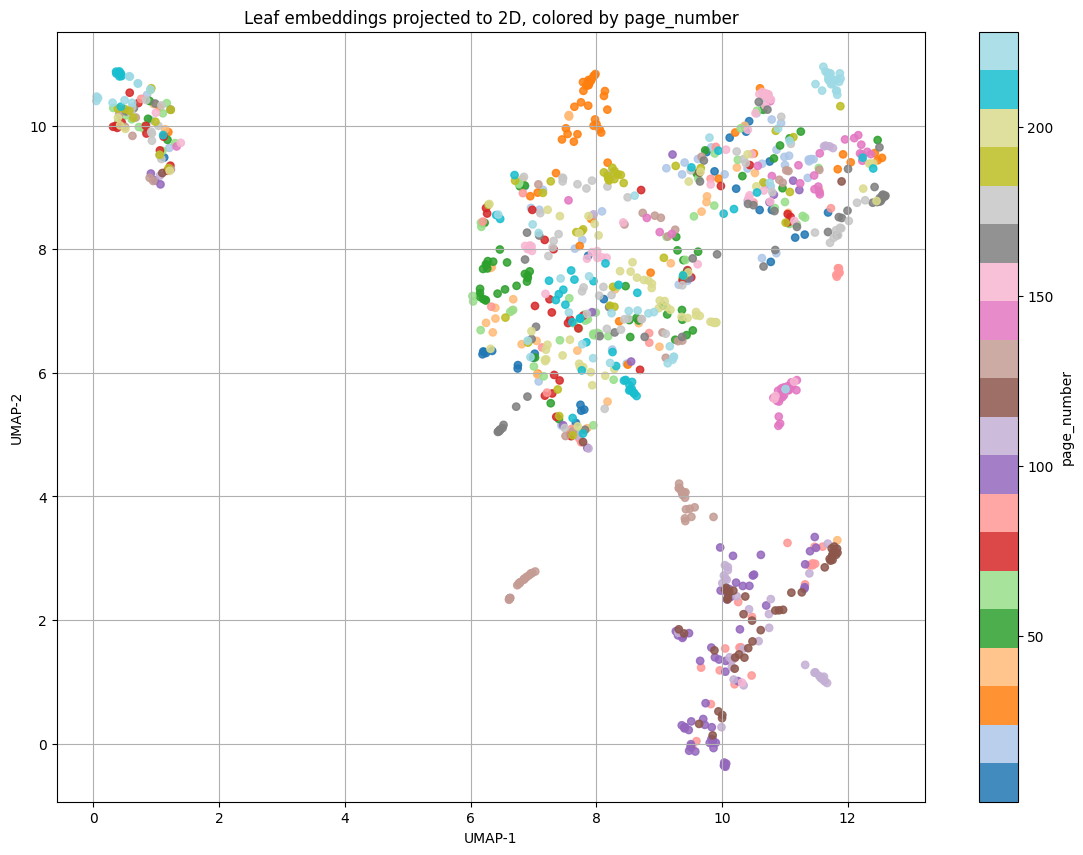

In [19]:
if len(embeddings) > 10:
    reducer = umap.UMAP(
        n_neighbors=min(15, len(embeddings) - 1),
        n_components=2,
        min_dist=0.1,
        metric="cosine",
        random_state=42,
    )
    coords = reducer.fit_transform(embeddings)
else:
    coords = PCA(n_components=2, random_state=42).fit_transform(embeddings)

plot_df = leaves_df.reset_index(drop=True).copy()
plot_df["x"] = coords[:, 0]
plot_df["y"] = coords[:, 1]
plot_df["page_number"] = plot_df["source_pages"].apply(first_page)

plt.figure(figsize=(14, 10))
sc = plt.scatter(
    plot_df["x"],
    plot_df["y"],
    c=plot_df["page_number"],
    cmap="tab20",
    s=28,
    alpha=0.85,
)
plt.colorbar(sc, label="page_number")
plt.title("Leaf embeddings projected to 2D, colored by page_number")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

# Trực quan hóa theo parent gần nhất

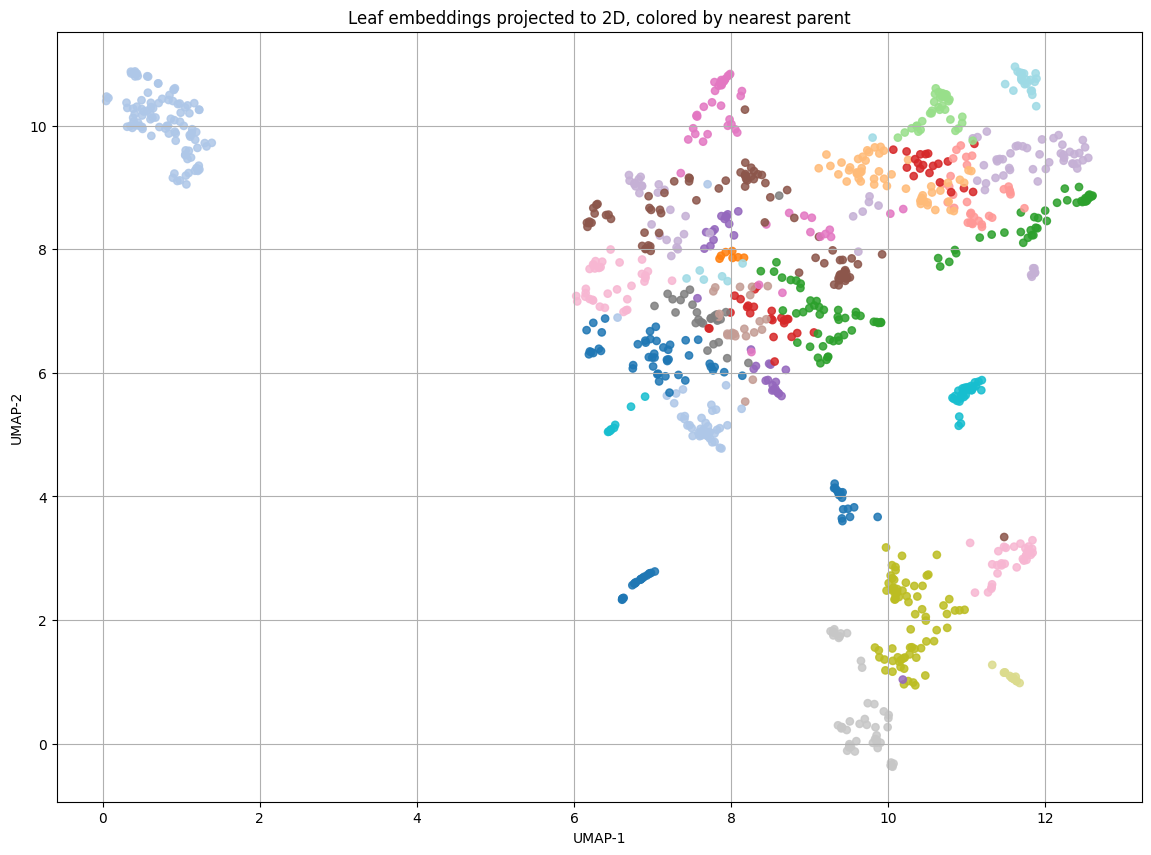

In [20]:
def nearest_parent(node_id):
    parents = parent_map.get(node_id, [])
    if not parents:
        return "NO_PARENT"
    return sorted(parents, key=lambda pid: node_depth.get(pid, 10**9))[0]

plot_df["nearest_parent"] = plot_df["node_id"].apply(nearest_parent)
parent_codes = pd.factorize(plot_df["nearest_parent"])[0]

plt.figure(figsize=(14, 10))
plt.scatter(
    plot_df["x"],
    plot_df["y"],
    c=parent_codes,
    cmap="tab20",
    s=28,
    alpha=0.85,
)
plt.title("Leaf embeddings projected to 2D, colored by nearest parent")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

# In các cụm lớn nhất

In [21]:
cluster_sizes = plot_df.groupby("nearest_parent").size().sort_values(ascending=False)
top_parents = cluster_sizes.head(10).index.tolist()

for pid in top_parents:
    sub = plot_df[plot_df["nearest_parent"] == pid]
    parent_row = nodes_df[nodes_df["node_id"] == pid]
    print("=" * 120)
    print("PARENT:", pid, "| depth:", node_depth.get(pid), "| size:", len(sub))
    if len(parent_row):
        print("Parent text:")
        print(parent_row.iloc[0]["text"][:600])
    print("Pages:", sorted(sub["page_number"].dropna().astype(int).unique().tolist()))
    print("Sample leaves:")
    for txt in sub["text"].head(3):
        print("-", str(txt)[:250].replace("\n", " "))

PARENT: node_35dd9a21e48076c6 | depth: 1 | size: 101
Parent text:
### Tóm tắt Tài liệu Y khoa

#### 1. Thông tin về Ban soạn thảo
- **Chủ biên**: PGS.TS. Nguyễn Thị Xuyên
- **Đồng Chủ biên**: PGS.TS. Nguyễn Quốc Anh, PGS.TS. Phạm Duệ, PGS.TS. Lương Ngọc Khuê
- **Ban biên soạn**: Các chuyên gia y khoa từ nhiều lĩnh vực khác nhau

#### 2. Tài liệu tham khảo
- Các tài liệu tham khảo bao gồm sách, bài báo khoa học, và các nguồn thông tin từ tổ chức y tế uy tín như WHO, CDC, và các trang web chuyên ngành.

#### 3. Các bệnh và tình trạng cần phòng ngừa
- **Phòng bệnh**: Các chương trình phòng chống ngộ độc, phòng chống rắn độc, và các loại ngộ độc thực phẩm (như m
Pages: [3, 15, 19, 23, 26, 37, 42, 47, 52, 59, 65, 71, 76, 80, 85, 94, 100, 111, 117, 126, 134, 140, 150, 155, 163, 167, 173, 177, 182, 189, 193, 198, 209, 215, 223, 228]
Sample leaves:
- Chủ biên PGS.TS. Nguyễn Thị Xuyên Đồng Chủ biên: PGS.TS. Nguyễn Quốc Anh PGS.TS. Phạm Duệ PGS.TS. Lương Ngọc Khuê Ban biên soạn PGS.TS. Phạm Duệ 

# Xem summary nodes theo depth

In [22]:
summary_df = nodes_df[~nodes_df["is_leaf"]].copy()
summary_df["child_count"] = summary_df["child_node_ids"].apply(lambda x: len(x) if isinstance(x, list) else 0)

summary_df[[
    "node_id", "depth", "child_count", "token_estimate", "source_pages", "text"
]].sort_values("depth").head(20)

,node_id,depth,child_count,token_estimate,source_pages,text
1037,node_5a90511045e5b9df,1,38,290,"[2, 127, 128, 129, 130, 131, 132, 133, 134]",### Tóm tắt tài liệu y khoa về ong đốt\n\n####...
1038,node_35dd9a21e48076c6,1,101,305,"[3, 15, 19, 23, 26, 37, 42, 47, 52, 59, 65, 71...",### Tóm tắt Tài liệu Y khoa\n\n#### 1. Thông t...
1039,node_54e2b7644ce9292c,1,34,311,"[11, 12, 13, 22, 28, 29, 41, 42, 50, 69, 83, 1...",### Tóm tắt các biện pháp điều trị ngộ độc hóa...
1040,node_a830682e8b62fd05,1,23,225,"[189, 219, 220, 221, 222, 224]",### Tóm tắt tài liệu y khoa\n\n#### Đại cương\...
1041,node_18033cb8c1802b6c,1,56,293,"[18, 30, 31, 33, 39, 40, 41, 49, 51, 64, 68, 6...",### Tóm tắt tài liệu y khoa\n\n#### 1. Áp lực ...
1042,node_f15250a7fe72147c,1,32,303,"[9, 10, 160, 161, 162, 170, 171, 172, 176, 177...",### Tóm tắt tài liệu y khoa\n\n#### 1. Xử lý t...
1043,node_3238296dd1df0efb,1,31,363,"[8, 14, 17, 21, 22, 28, 45, 50, 57, 68, 74, 83...",### Tóm tắt tài liệu y khoa\n\n#### Đại cương\...
1044,node_b488b48cac35ba09,1,41,215,"[6, 7, 16, 17, 25, 32, 44, 56, 62, 67, 77, 78,...",### Tóm tắt tài liệu y khoa\n\n#### 1. Các chữ...
1045,node_fcbc40ae4a15c53c,1,50,283,"[9, 22, 39, 49, 55, 83, 130, 162, 165, 175, 19...",### Tóm tắt tài liệu y khoa\n\n#### 1. Nguyên ...
1046,node_81e81fcba151838c,1,48,315,"[18, 19, 23, 25, 33, 35, 46, 49, 58, 64, 70, 8...",### Tóm tắt các mục quan trọng trong tài liệu ...


# Kiểm tra root

In [23]:
root_ids = tree["stats"]["root_node_ids"]
print("Root ids:", root_ids)

for rid in root_ids:
    row = nodes_df[nodes_df["node_id"] == rid]
    if len(row):
        print("\nROOT TEXT:")
        print(row.iloc[0]["text"][:1000])

Root ids: ['node_ad487ae3f889322f']

ROOT TEXT:
### Tóm tắt tài liệu y khoa

#### 1. Nguyên nhân
- **Trụy Mạch - Tụt Huyết Áp**:
  - Giảm thể tích tuần hoàn.
  - Sốc phản vệ.
  - Giãn mạch.
  - Viêm cơ tim nhiễm độc.
  - Xét nghiệm xác định bằng cách truyền dịch.

- **Nguyên Nhân Khác**:
  - Uống phối hợp benzodiazepine với thuốc gây co giật.
  - Uống phối hợp benzodiazepine với thuốc ảnh hưởng nhịp tim.
  - Uống phối hợp benzodiazepine với thuốc độc với cơ tim.

#### 2. Triệu chứng
- **Tim Mạch**:
  - Ranh ẩm, ran ngáy, rít ở phổi.
  - Nhịp chậm <60 lần/phút.
  - Hội chứng Nicotin: máy cơ tự nhiên, co cứng hoặc liệt cơ, phản xạ gân xương tăng nhạy.
  - Hội chứng bệnh lý thần kinh trung ương: rối loạn ý thức, điểm Glasgow giảm, co giật.

- **Hô Hấp**:
  - Suy hô hấp: tràn khí màng phổi, tràn khí trung thất, viêm phổi sặc, suy hô hấp cấp.
  - Suy hô hấp dần dần, phổi bình thường vài ngày đầu, sau đó thâm nhiễm, mờ hai phổi, xơ phổi.

- **Gan**:
  - Viêm gan, thường xuất hiện muộn, phosp

In [24]:
print("Leaf nodes:", tree["stats"]["leaf_nodes"])
print("Total nodes:", tree["stats"]["total_nodes"])
print("Levels:", tree["stats"]["levels"])
print("Embedding dim:", tree["config"]["embedding_dim"])
print("Page mapping uses chunks.jsonl via source_chunk_id -> id")

Leaf nodes: 1037
Total nodes: 1081
Levels: 5
Embedding dim: 1024
Page mapping uses chunks.jsonl via source_chunk_id -> id
